In [13]:
from typing import Dict, List, Any
from numpy.typing import NDArray

from model_ranking import (
    get_summary_results, 
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    to_target_transfer_correlations_with_norm,
    correlation_table,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm

In [14]:
consis_keys={
    "FlyWing": "AdaRandError_consis",
    "Ovules": "AdaRandError_consis",
    "PNAS": "AdaRandError_consis",
}

result_folders={
    "FlyWing": "finetuned_fullslice",
    "Ovules": "finetuned_fullslice",
    "PNAS": "finetuned_fullslice",
}

per_target_norms: Dict[str, List[None]] = {
    "FlyWing": [None],
    "Ovules": [None],
    "PNAS": [None],
}

# per_target_norms: Dict[str, List[Tuple[float,float]]] = {
#     "FlyWing": [(5.0, 95.0)],
#     "Ovules": [(5.0, 95.0)],
#     "PNAS": [(5.0, 95.0)],
# }

perf_key = "MAP_05_095"
approach="consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells"

In [15]:
NA_UNet_source_models_PTarget = {
    "Ovules": "OvtoP_def_ov_model_NA1",
}
Res_source_models_PTarget = {
    "FlyWing": "FwtoP_def_fw_model_Res2",
    "Ovules": "OvtoP_def_ov_model_Res1",
}
Unet_source_models_PTarget = {
    "FlyWing": "FwtoP_def_fw_model_Unet2",
    "Ovules": "OvtoP_def_ov_model_UNet1",
}
P_Target_models = [
    NA_UNet_source_models_PTarget, 
    Res_source_models_PTarget, 
    Unet_source_models_PTarget, 
]

In [16]:
NA_UNet_source_models_OvTarget = {
    "PNAS": "PtoOv_def_p_model_NA1",
}
Res_source_models_OvTarget = {
    "FlyWing": "FwtoOv_def_fw_model_Res2",
    "PNAS": "PtoOv_def_p_model_Res1",
}
Unet_source_models_OvTarget = {
    "FlyWing": "FwtoOv_def_fw_model_Unet2",
    "PNAS": "PtoOv_def_p_model_UNet1",
}
Ov_Target_models = [
    NA_UNet_source_models_OvTarget, 
    Res_source_models_OvTarget, 
    Unet_source_models_OvTarget, 
]

In [17]:
NA_UNet_source_models_FwTarget = {
    "Ovules": "OvtoFw_def_ov_model_NA1",
    "PNAS": "PtoFw_def_p_model_NA1",
}
Res_source_models_FwTarget = {
    "PNAS": "PtoFw_def_p_model_Res1",
    "Ovules": "OvtoFw_def_ov_model_Res1",
}
Unet_source_models_FwTarget = {
    "PNAS": "PtoFw_def_p_model_UNet1",
    "Ovules": "OvtoFw_def_ov_model_UNet1",
}
Fw_Target_models = [
    NA_UNet_source_models_FwTarget, 
    Res_source_models_FwTarget, 
    Unet_source_models_FwTarget, 
]

In [18]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-005", "a005-01", "a01-015", "a015-02", "a02-025"],
}   
targets = ["FlyWing", "Ovules", "PNAS"]

target_models = {
    "FlyWing": Fw_Target_models,
    "Ovules": Ov_Target_models,
    "PNAS": P_Target_models,
}

In [19]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
for i, target in enumerate(targets):
    # if target == "FlyWing":
    #     sources = ["Ovules", "PNAS"]
    # elif target == "Ovules":
    #     sources = ["FlyWing", "PNAS"]
    # else:
    #     sources = ["FlyWing", "Ovules"]

    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    source_model_types = target_models[target]

    for model_type in source_model_types:
        if target == "Ovules":
            if "NA" in model_type["PNAS"]:
                sources = ["PNAS"]
            else:
                sources = ["FlyWing", "PNAS"]
        elif target == "PNAS":
            if "NA" in model_type["Ovules"]:
                sources = ["Ovules"]
            else:
                sources = ["FlyWing", "Ovules"]
        else:
            sources = ["Ovules", "PNAS"]
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 26.86it/s]


Source: PNAS


100%|██████████| 1/1 [00:00<00:00, 33.20it/s]


Source: Ovules


...

100%|██████████| 1/1 [00:00<00:00, 34.18it/s]


Source: FlyWing


100%|██████████| 1/1 [00:00<00:00, 21.08it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 31.23it/s]


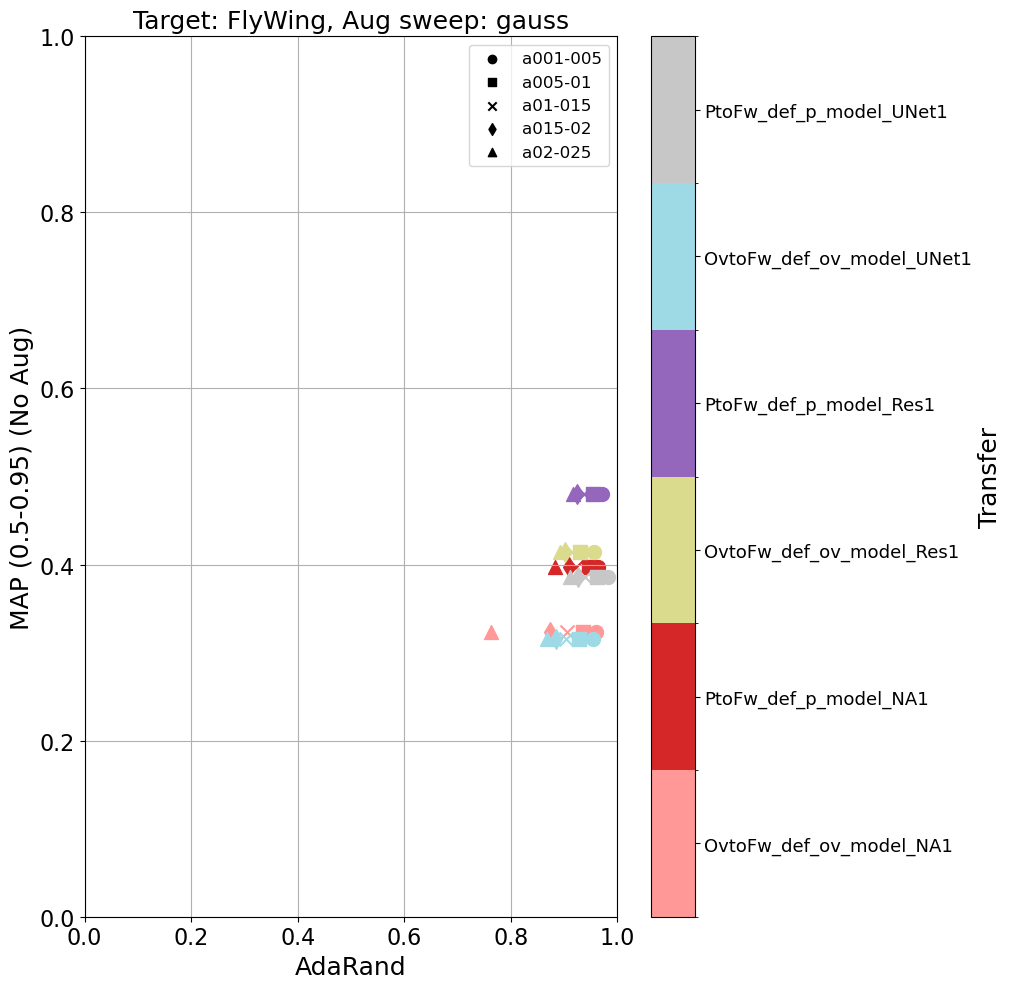

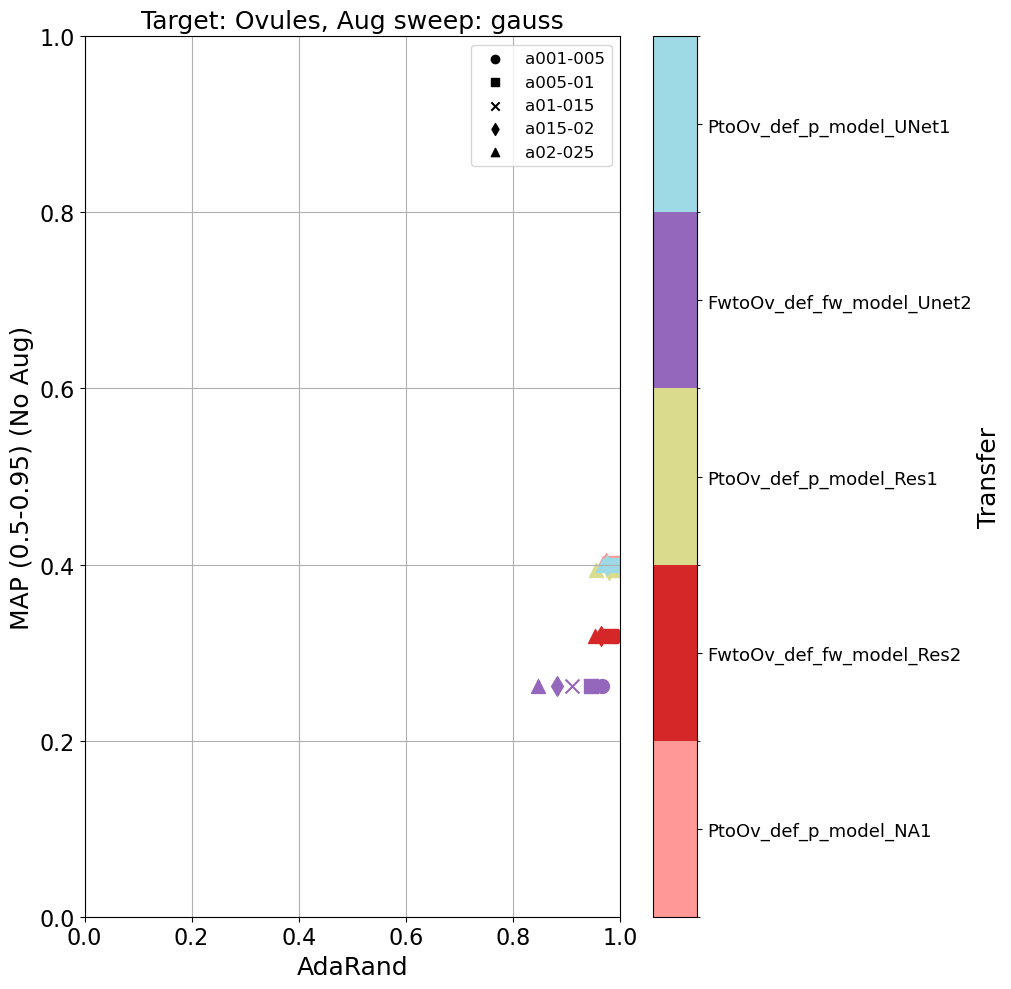

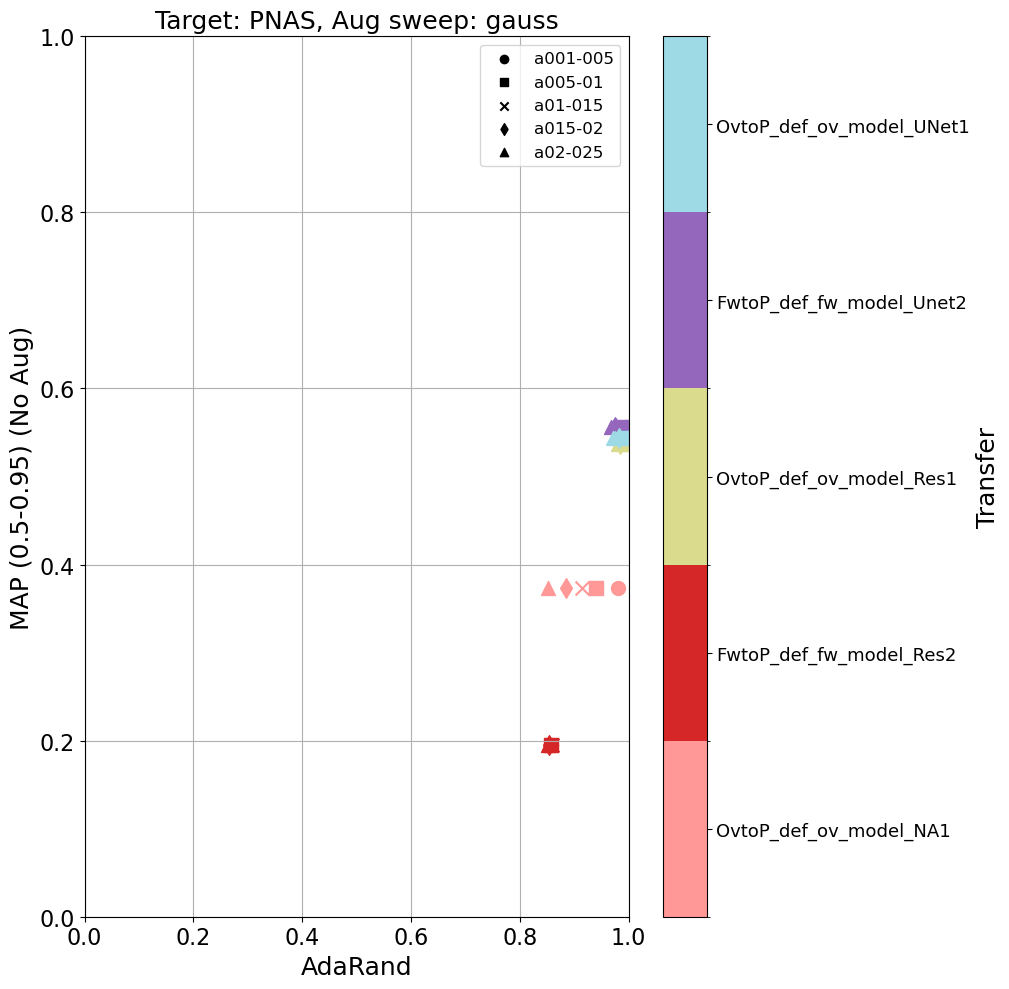

In [20]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        transfer_metric_name="MAP (0.5-0.95)",
        invert_consis_metric= True,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

In [21]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_forg_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss",
    invert_consis_score=True
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

gauss: a001-005
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.47   0.43        0.43  0.46     0.36
     Ovules   0.80     0.08   0.90        0.07  0.93     0.02
     PNAS     0.40     0.46   0.60        0.35  0.93     0.02
gauss: a005-01
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.33     0.49   0.43        0.44  0.52     0.29
     Ovules   0.40     0.47   0.60        0.32  0.91     0.03
     PNAS     0.40     0.43   0.60        0.39  0.99     0.00
gauss: a01-015
                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito FlyWing  0.47     0.26    0.6        0.26  0.75     0.09
     Ovules   0.60     0.23    0.7        0.24  0.90     0.04
     PNAS     0.40     0.54    0.6        0.33  0.99     0.00
gauss: a015-02
         

# Save Results

In [23]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance

In [ ]:
import json
import os
from model_ranking.results import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells/transfer_results/consistency/finetuned_fullslice"
if not os.path.exists(save_path):
    os.makedirs(save_path)

# for i, alpha in enumerate(selected_augmentations['gauss']):
#     per_target_consistency: Dict[str, Dict[str,float]] = {}
#     for target, per_model_consistency in per_target_forg_consistency.items():
#         per_target_consistency[target] = {}
#         for model, consistency in per_model_consistency.items():
#             per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

#     with open(os.path.join(save_path, f"transfer_self_supervised_Gauss_{alpha}_FORG_ARE_scores.json"), "w") as f:
#         results: Dict[str, Any] = {
#             "transfer_scores": convert_numpy_types(per_target_consistency),
#         }
#         json.dump(results, f, indent=4)

# with open(os.path.join(save_path, f"transfer_performance_MAP_scores.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "performance_scores": convert_numpy_types(per_target_performance),
#     }
#     json.dump(results, f, indent=4)


# Background Consistency

In [11]:
per_target_bckg_consistency: Dict[str, Dict[str, Dict[str, Dict[str, NDArray[Any]]]]] = {}
per_target_bckg_performance: Dict[str, Dict[str, Dict[str, NDArray[Any]]]] = {}

for i, target in enumerate(targets):
    if target == "VNC":
        sources = ["EPFL", "Hmito", "Rmito"]
        #sources = ["Hmito", "Rmito"]
    elif target == "Hmito":
        sources = ["EPFL", "Rmito", "VNC"]
    elif target == "Rmito":
        sources = ["EPFL", "Hmito", "VNC"]
    else:
        sources = ["Hmito", "Rmito", "VNC"]
    per_source_bckg_consistency = {}
    per_source_bckg_performance = {}

    source_model_types = target_models[target]

    for model_type in source_model_types:
        if target == "EPFL":
            if "Unetr" in model_type["Hmito"]:
                sources = ["Hmito", "Rmito"]
        elif target == "VNC":
            if "Unetr" in model_type["Hmito"]:
                sources = ["EPFL", "Hmito", "Rmito"]
                #sources = ["Hmito", "Rmito"]
        elif target == "Hmito":
            if "Unetr" in model_type["EPFL"]:
                sources = ["EPFL", "Rmito"]
        elif target == "Rmito":
            if "Unetr" in model_type["EPFL"]:
                sources = ["EPFL", "Hmito"]

        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys_bckg,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            consis_postfix="median",
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_bckg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_bckg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
        
    
    per_target_bckg_consistency[target] = per_source_bckg_consistency
    per_target_bckg_performance[target] = per_source_bckg_performance

    

Source: Hmito


  0%|          | 0/1 [00:00<?, ?it/s]


KeyError: "Unable to synchronously open object (object 'EI_consis_bckg_median' doesn't exist)"

In [12]:
per_target_cmb_consistency = cmb_consistency_score_weighted_average(
    per_target_forg_consistency,
    per_target_bckg_consistency,
    w_fg=0.5,
    w_bg=0.5,
    perturbation_key="gauss",
)

KeyError: 'EPFL'

In [13]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_cmb_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

NameError: name 'per_target_cmb_consistency' is not defined

In [14]:
per_target_KT, per_target_SP, per_target_PE = to_target_transfer_correlations_with_norm(
    targets=targets,
    transfer_metric_per_target=per_target_cmb_consistency,
    performance_per_target=per_target_forg_performance,
    num_aug_alphas=len(selected_augmentations["gauss"]),
    perturbation_key="gauss"
)
for i in range(len(selected_augmentations['gauss'])):
    print(f"gauss: {selected_augmentations['gauss'][i]}")
    df = correlation_table(
        per_target_KT,
        per_target_SP,
        per_target_PE,
        targets,
        idx=i,
    )
    print(df)

NameError: name 'per_target_cmb_consistency' is not defined

# Save Results

In [63]:
import json
import os
from model_ranking import convert_numpy_types

save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/self_supervised/CMB"
if not os.path.exists(save_path):
    os.makedirs(save_path)

for i, alpha in enumerate(selected_augmentations['gauss']):
    per_target_consistency: Dict[str, Dict[str,float]] = {}
    for target, per_model_consistency in per_target_cmb_consistency.items():
        per_target_consistency[target] = {}
        for model, consistency in per_model_consistency.items():
            per_target_consistency[target][model] = consistency['norm_Normalize']['gauss'][i]

    with open(os.path.join(save_path, f"transfer_self_supervised_Gauss_{alpha}_CMB_05f_05b_EI_scores.json"), "w") as f:
        results: Dict[str, Any] = {
            "transfer_scores": convert_numpy_types(per_target_consistency),
        }
        json.dump(results, f, indent=4)



In [16]:
per_target_performance: Dict[str, Dict[str,float]] = {}
for target, per_model_performance in per_target_forg_performance.items():
    per_target_performance[target] = {}
    for model, performance in per_model_performance.items():
        if isinstance(performance, dict):
            per_target_performance[target][model] = performance['norm_Normalize']
        else:
            per_target_performance[target][model] = performance


In [ ]:
# import json
# import os
# from model_ranking import convert_numpy_types
# save_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/self_supervised/CMB"
# if not os.path.exists(save_path):
#     os.makedirs(save_path)
# with open(os.path.join(save_path, "transfer_self_supervised_GaussSweep_CMB_05f_05b_EI_scores_with_NORM.json"), "w") as f:
#     results: Dict[str, Any] = {
#         "transfer_scores": convert_numpy_types(per_target_cmb_consistency),
#     }
#     json.dump(results, f, indent=4)